<a href="https://colab.research.google.com/github/DaviTeobaldo/Curso-Intensivo-de-Computacao-Quantica/blob/main/Par_de_Bell_Qiskit_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unidade: Gerando um Par de Bell com Qiskit


Nesta unidade é apresentada a construção computacional de um **estado de Bell**, uma classe de estados maximamente emaranhados composta por dois qubits. O emaranhamento quântico constitui um recurso físico exclusivo da Mecânica Quântica, não possuindo equivalente na Computação Clássica.

O objetivo é compreender como operações unitárias locais e controladas podem transformar um estado inicialmente separável em um estado cujas propriedades somente podem ser descritas pelo sistema como um todo.

Durante a atividade serão abordados:

- representação matricial de sistemas com dois qubits;
- produto tensorial de estados quânticos;
- aplicação das portas **Hadamard (H)** e **Controlled-NOT (CNOT)**;
- construção do primeiro estado de Bell;
- análise das correlações observadas após a medição.

## Estado inicial do sistema

Considerando dois qubits inicializados em $|0\rangle$, o estado inicial do sistema é obtido pelo produto tensorial

$$
|00\rangle=
|0\rangle\otimes|0\rangle.
$$

Na representação vetorial,

$$
|00\rangle=
\begin{bmatrix}
1\\
0\\
0\\
0
\end{bmatrix}.
$$

Observe que o espaço de estados deixa de possuir dimensão $2$ e passa a possuir dimensão $2^2=4$. De maneira geral, um registrador contendo $n$ qubits é descrito em um espaço vetorial de dimensão $2^n$, característica responsável pelo crescimento exponencial da capacidade de representação dos sistemas quânticos.

In [1]:
!pip -q install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.7 MB/s eta 0:00:00


In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

## Fundamentação

Estado inicial:

$$|00\rangle=\begin{bmatrix}1\\0\\0\\0\end{bmatrix}.$$

Na convenção do Qiskit, os estados são escritos como $|q_1q_0\rangle$.

Aplicando Hadamard no qubit 0:

$$H=\frac1{\sqrt2}\begin{bmatrix}1&1\\1&-1\end{bmatrix}$$

$$ (I\otimes H)|00\rangle=\frac{|00\rangle+|01\rangle}{\sqrt2}. $$

Depois aplica-se uma CNOT com controle em $q_0$ e alvo em $q_1$:

$$\frac{|00\rangle+|01\rangle}{\sqrt2}\rightarrow
\frac{|00\rangle+|11\rangle}{\sqrt2}=|\Phi^+\rangle.$$


## Circuito

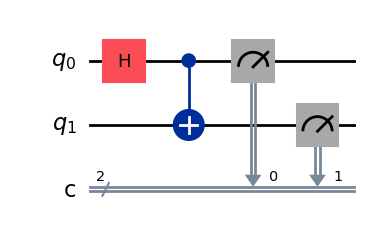

In [4]:
qc=QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])
display(qc.draw('mpl'))

## Simulação

In [5]:
sim=AerSimulator()
result=sim.run(qc,shots=1000).result()
counts=result.get_counts()
print(counts)

{'11': 504, '00': 496}


## Histograma

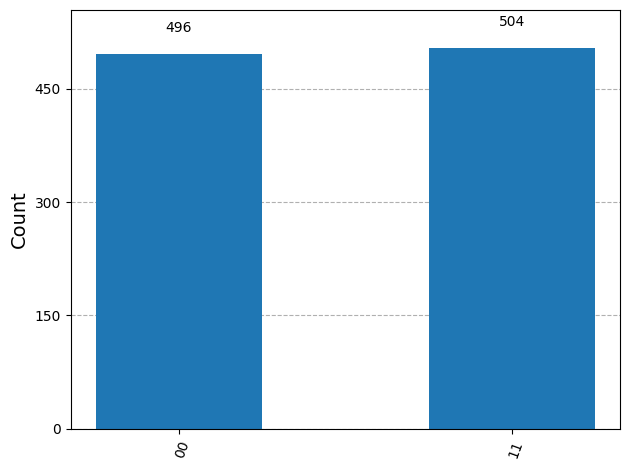

In [6]:
fig=plot_histogram(counts)
display(fig)
plt.show()